In [1]:
import warnings
warnings.filterwarnings("ignore")
import logging
from statkit.decision import NetBenefitDisplay
import scipy
from sklearn.metrics import * 
import pandas as pd
import seaborn as sns
import numpy as np
import shap 
import torch
import os
import inspect 
import torch.nn as nn
import matplotlib.pyplot as plt
import pickle
from numpy import sqrt
from numpy import argmax
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from matplotlib import pyplot
from torchinfo import summary as torchsummary
from torchvision import models, transforms
from model import init_model
from matplotlib import pyplot
from pathlib import Path
sns.set(rc={'figure.figsize':(11.7,8.27)})
pd.options.display.max_rows = 999
pd.options.display.max_columns = 999




# Parameters 

In [2]:
ROOT_DIR = Path(os.path.dirname(os.path.abspath('')))
TOTAL_TRAIN_SAMPLES = 50
TOTAL_TEST_SAMPLES = 10
CHANNELS = 3
DEVICE = "cuda:1"
OCT_PRESENCE = "Usando OCT"
DUAL_IMAGE = "Dual Image"
DATA_PATH = "../data.csv"
SUMMARY_PATH = "../model_summary.csv"
HISTORY_PATH = "../history.csv"
FT_SIZE = 24
ARQ1 = "SI"
ARQ2 = "SIT"
ARQ3 = "DI"
ARQ4 = "DIT"

# Functions

In [3]:
def get_samples_from_dataloader(dataloader, size):
    """
        Return photos1, photos2, ft_numerical, labels
    """ 
    
    list_of_photos_1 = []
    list_of_photos_2 = []
    list_of_features = []
    list_of_labels = []

    
    positive_class = 0
    negative_class = 0 
    
    for photos1, photos2, numericalft, labels in dataloader:
        for i in range(len(labels)):
            if int(labels[i].numpy()) == 0 and negative_class >= (size / 2):
                continue
            elif int(labels[i].numpy()) == 0 and negative_class < (size / 2):
                negative_class += 1
                
            if int(labels[i].numpy()) == 1 and positive_class >= (size / 2):
                continue 
            elif int(labels[i].numpy()) == 1 and positive_class < (size / 2):
                positive_class += 1
                
            list_of_photos_1.append(photos1[i])
            list_of_photos_2.append(photos2[i])
            list_of_features.append(numericalft[i])
            list_of_labels.append(labels[i].numpy())
        
        if len(list_of_labels) >= size:
            break
        
    
            
    photos1 = torch.stack(list_of_photos_1)
    photos2 = torch.stack(list_of_photos_2)
    ft_numerical = torch.stack(list_of_features)
    labels  = np.array(list_of_labels)
    
    return (photos1, photos2, ft_numerical, labels)


In [4]:
def load_model_and_loaders(model_row):
    """
        Return model, train_loader, val_loader
    """ 
    model_name = model_row["backbone"].values[0]
    pretrained = False
    feature_extract = False
    double_img_bool = True if model_row["double_img"].values[0] > 0 else False
    output_tab = int(model_row["output_tab"].values[0]) if model_row["output_tab"].values[0] > 0 else None 
    model, input_size = init_model(model_name,pretrained, feature_extract, double_img_bool, output_tab, FT_SIZE)
    model.load_state_dict(torch.load("../models/" + str(model_id) + "/" + "model"+ ".pth"))
    train_loader = torch.load("../models/" + str(model_id) + "/train_dataloader" + ".pth")
    val_loader = torch.load("../models/" + str(model_id) + "/val_dataloader" + ".pth")
    
    val_loader.dataset.root_dir = ROOT_DIR
    train_loader.dataset.root_dir = ROOT_DIR
    
    return model, train_loader, val_loader, input_size

In [5]:
def create_explainers(model, device, photos1_train, photos2_train, ft_numerical_train, 
                                     photos1_val, photos2_val, ft_numerical_val, input_size):
    """
        Return shap_values_photo1, shap_values_photo2, shap_values_nuermical
    """ 
    
    model = model.to(device)
    explainer = shap.DeepExplainer(model, [photos1_train.to(device),photos2_train.to(device),ft_numerical_train.to(device)])
    shap_values_photo1, shap_values_photo2, shap_values_numerical = explainer.shap_values([photos1_val.to(device),photos2_val.to(device), ft_numerical_val.to(device)])
    
    photos1_list = []
    photos2_list = []
    for i in range(len(photos1_val)):
        photos1_list.append(imshow(photos1_val[i]))
        photos2_list.append(imshow(photos2_val[i]))
        
    
    photos1_numpy = np.asarray(photos1_list)
    photos2_numpy = np.asarray(photos2_list)
    
    return (shap_values_photo1.reshape(-1, input_size, input_size, CHANNELS), 
            shap_values_photo2.reshape(-1, input_size, input_size, CHANNELS), 
            shap_values_numerical,
            photos1_numpy, 
            photos2_numpy)

In [6]:
def plot_image(shap_values, photos, total):
    
    return shap.image_plot(shap_values[:total], photos[:total])

In [7]:
def imshow(image):
    npimg = image.numpy()
    npimg = np.transpose(npimg, (1,2,0))
    npimg = ((npimg * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406])
    return npimg

In [8]:
def shapley_feature_ranking(shap_values):
    feature_order = np.argsort(np.mean(np.abs(shap_values), axis=0))
    return pd.DataFrame(
        {
            "features": [features_name[i] for i in feature_order][::-1],
            "importance": [
                np.mean(np.abs(shap_values), axis=0)[i] for i in feature_order
            ][::-1],
        }
    )

In [9]:
def get_rank_per_group(df_max,df_avg):
    dict_rows = {}
    dict_rows["Backbone"] = []
    dict_rows[OCT_PRESENCE] = []
    dict_rows[DUAL_IMAGE] = []
    dict_rows["Max Auc Rank"] = []
    dict_rows["Avg Auc Rank"] = []
 
 
    df_max = df_max.sort_values(by=["backbone",OCT_PRESENCE,DUAL_IMAGE])
    df_avg = df_avg.sort_values(by=["backbone",OCT_PRESENCE,DUAL_IMAGE])
    
    
    for index, row in df_max.iterrows():
        dict_rows["Backbone"].append(row["backbone"])
        dict_rows[OCT_PRESENCE].append(row[OCT_PRESENCE])
        dict_rows[DUAL_IMAGE].append(row[DUAL_IMAGE])
        dict_rows["Max Auc Rank"].append(row["rank_max_auc_oct_double"])
        
    for index, row in df_avg.iterrows():
        dict_rows["Avg Auc Rank"].append(row["rank_avg_auc_oct_double"])
        
    df_rank_per_group = pd.DataFrame.from_dict(dict_rows)
    return df_rank_per_group

# Preprocessing

In [10]:
data = pd.read_csv(DATA_PATH)
summary = pd.read_csv(SUMMARY_PATH)
filter_summary = pd.read_csv("../filter_top1.csv")
df_peak = pd.read_csv("../df_peak_mem_summary.csv")
history = pd.read_csv(HISTORY_PATH)

In [11]:
summary.dropna(axis="columns",how="all").columns

Index(['model_id', 'k_fold', 'frac_val', 'val_best_acc', 'val_best_auc',
       'val_best_sp', 'val_best_sn', 'val_avg_acc', 'val_avg_auc',
       'val_avg_sp', 'val_avg_sn', 'train_best_acc', 'train_best_auc',
       'train_best_sp', 'train_best_sn', 'train_avg_acc', 'train_avg_auc',
       'train_avg_sp', 'train_avg_sn', 'host_name', 'optim', 'lr', 'scheduler',
       'randaugop', 'epochs', 'double_img', 'output_tab', 'backbone',
       'early_start', 'patient_el', 'timestamp', 'total_hours',
       'average_cross_hours', 'torchvision_version', 'torch_version',
       'history_added', 'shap_val', 'shap_oos', 'pred_val', 'pred_oos',
       'batch_size', 'Usando OCT', 'Dual Image', 'group_backbone',
       'regnet_vs_other', 'rank_max_auc', 'rank_avg_auc',
       'rank_max_auc_oct_double', 'rank_avg_auc_oct_double', 'rank_avg',
       'inference_time'],
      dtype='object')

In [12]:
filter_summary.columns

Index(['model_id', 'k_fold', 'frac_val', 'val_best_acc', 'val_best_auc',
       'val_best_sp', 'val_best_sn', 'val_avg_acc', 'val_avg_auc',
       'val_avg_sp', 'val_avg_sn', 'train_best_acc', 'train_best_auc',
       'train_best_sp', 'train_best_sn', 'train_avg_acc', 'train_avg_auc',
       'train_avg_sp', 'train_avg_sn', 'host_name', 'optim', 'lr', 'epochs',
       'double_img', 'output_tab', 'backbone', 'early_start', 'timestamp',
       'total_hours', 'average_cross_hours', 'torchvision_version',
       'torch_version', 'history_added', 'shap_val', 'shap_oos', 'pred_val',
       'pred_oos', 'batch_size', 'Usando OCT', 'Dual Image', 'group_backbone',
       'regnet_vs_other', 'rank_max_auc', 'rank_avg_auc',
       'rank_max_auc_oct_double', 'rank_avg_auc_oct_double', 'rank_avg'],
      dtype='object')

In [13]:
cross = summary[summary["scheduler"] == "plateau"]

In [14]:
cross = cross[cross["randaugop"] == 0]

In [15]:
cross.shape

(28, 56)

In [16]:
cross[["model_id","backbone","shap_val","shap_oos","pred_val","pred_oos"]]

,model_id,backbone,shap_val,shap_oos,pred_val,pred_oos
858,a50e719c914f4e07a6dc5fe36c191780,regnet16x,1,1,1,1
859,1a500bc2ea8340bcbcad33a2f440b7b7,regnet16x,1,1,1,1
860,de1ebc7a3d6441eab6255419c53cfd94,inception,1,1,1,1
861,5addd14041e54ea0b45050f8b2b840e2,regnet32x,1,1,1,1
862,a9607c10eea64a0487913d8b087664a5,inception,1,1,1,1
863,a948d6ee6c3f4fbb8804e4a51aea2890,inception,1,1,1,1
864,86d27a1507a8431aada713f3f2b49a86,resnet,0,0,1,1
865,1c6f3dc7ee844662b288be93b1c91235,regnet32y,1,1,1,1
866,f13247f5d3414429857dbe30480d27b8,mobile,1,1,1,1
867,ee824607e9f04221880088fcb2543986,shuffle,1,1,1,1


In [17]:
cross[cross["output_tab"] == 0]

,model_id,k_fold,frac_val,val_best_acc,val_best_auc,val_best_sp,val_best_sn,val_avg_acc,val_avg_auc,val_avg_sp,val_avg_sn,train_best_acc,train_best_auc,train_best_sp,train_best_sn,train_avg_acc,train_avg_auc,train_avg_sp,train_avg_sn,host_name,optim,lr,scheduler,randaugop,epochs,double_img,output_tab,backbone,early_start,patient_el,timestamp,total_hours,average_cross_hours,torchvision_version,torch_version,history_added,shap_val,shap_oos,pred_val,pred_oos,batch_size,Usando OCT,Dual Image,group_backbone,regnet_vs_other,rank_max_auc,rank_avg_auc,Unnamed: 47,Unnamed: 46,rank_max_auc_oct_double,rank_avg_auc_oct_double,rank_avg,Unnamed: 50,Unnamed: 51,inference_time,Unnamed: 55
858,a50e719c914f4e07a6dc5fe36c191780,5.0,NaN,0.921053,0.898804,0.991150,0.957447,0.816615,0.758205,0.894366,0.622044,0.947195,0.931705,0.993151,0.893855,0.901829,0.858910,0.956714,0.761106,magneto,radam,0.0010,plateau,0,100.0,0.0,0.0,regnet16x,30.0,10,2022-12-17 23:05:14.946199,38:31:58.42,07:42:23.59,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.044,NaN
859,1a500bc2ea8340bcbcad33a2f440b7b7,5.0,NaN,0.907895,0.888335,0.990654,0.970588,0.798468,0.723501,0.897845,0.549158,0.922442,0.888366,0.986301,0.932961,0.856809,0.794011,0.936859,0.651162,magneto,radam,0.0001,plateau,0,100.0,0.0,0.0,regnet16x,30.0,10,2022-12-17 23:08:14.658931,38:34:58.14,07:42:59.54,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.039,NaN
860,de1ebc7a3d6441eab6255419c53cfd94,5.0,NaN,0.894737,0.858923,1.000000,0.941176,0.782866,0.712219,0.880475,0.543962,0.947195,0.931750,1.000000,0.897590,0.883244,0.833869,0.945991,0.721746,magneto,ranger,0.0005,plateau,0,100.0,0.0,0.0,inception,30.0,10,2022-12-17 23:59:53.626361,39:26:29.27,07:53:17.78,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.043,NaN
861,5addd14041e54ea0b45050f8b2b840e2,5.0,NaN,0.888158,0.881854,1.000000,0.893617,0.809317,0.747094,0.892963,0.601225,0.940594,0.915429,0.981818,0.860335,0.897387,0.852200,0.955205,0.749195,magneto,radam,0.0010,plateau,0,100.0,0.0,0.0,regnet32x,30.0,10,2022-12-18 17:58:38.694663,25:03:17.29,05:00:39.44,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.036,NaN
862,a9607c10eea64a0487913d8b087664a5,5.0,NaN,0.868421,0.810740,1.000000,0.818182,0.776733,0.682587,0.899573,0.465601,0.886326,0.830382,0.997743,0.715976,0.811004,0.714366,0.935078,0.493653,magneto,sgd,0.0100,plateau,0,100.0,0.0,0.0,inception,30.0,10,2022-12-18 18:20:10.940602,25:24:52.66,05:04:58.50,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.044,NaN
863,a948d6ee6c3f4fbb8804e4a51aea2890,5.0,NaN,0.921053,0.898804,1.000000,0.911765,0.791776,0.723413,0.886357,0.560469,0.945634,0.925988,1.000000,0.881657,0.883089,0.833037,0.946984,0.719090,magneto,ranger,0.0010,plateau,0,100.0,0.0,0.0,inception,30.0,10,2022-12-18 18:34:43.468383,25:39:25.19,05:07:53.01,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.044,NaN


In [18]:
cross["Learning Decay"] = "Sim"
filter_summary["Learning Decay"] = "Não"

In [19]:
filtered_cross = cross[["model_id","backbone","val_best_auc","val_avg_auc","optim","lr","output_tab","Learning Decay","inference_time"]]
filtered_top1 = filter_summary[["backbone","val_best_auc","val_avg_auc","optim","lr","output_tab","Learning Decay"]]
total = pd.concat([filtered_cross, filtered_top1])
total[OCT_PRESENCE] = np.where(total['output_tab'] > 0, 'Sim', 'Não')


Text(0, 0.5, 'Melhor AUC (Teste)')

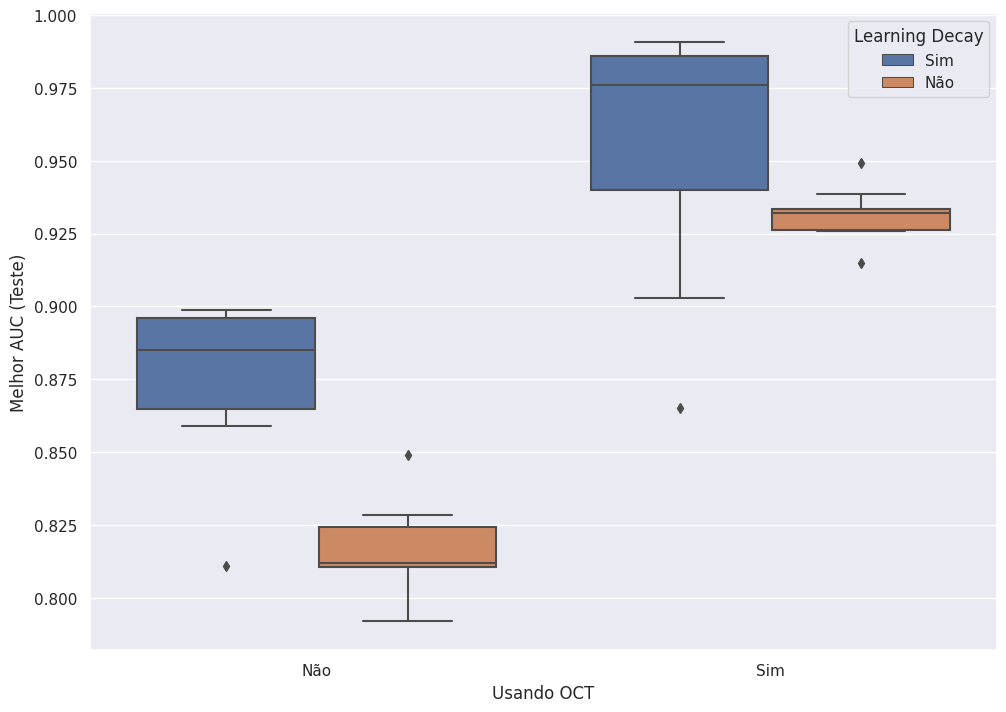

In [20]:
ax = sns.boxplot(total, hue="Learning Decay", x=OCT_PRESENCE, y="val_best_auc")
ax.set_ylabel("Melhor AUC (Teste)")

In [21]:
renamed_cross = filtered_cross.rename(columns={"val_best_auc": "val_best_auc_decay","val_avg_auc": "val_avg_auc_decay"})

In [22]:
total = renamed_cross.drop(columns="Learning Decay").merge(filtered_top1.drop(columns="Learning Decay"), how="inner", on=["backbone","optim","lr","output_tab"])

In [23]:
total[OCT_PRESENCE] = np.where(total['output_tab'] > 0, 'Sim', 'Não')

In [24]:
total["best_auc_improvement(%)"] = round((100 * total["val_best_auc_decay"] / total["val_best_auc"]) - 100, 2)
total["avg_auc_improvement(%)"] = round((100 * total["val_avg_auc_decay"] / total["val_avg_auc"]) - 100, 2)

In [25]:
total.groupby("backbone").count()

,model_id,val_best_auc_decay,val_avg_auc_decay,optim,lr,output_tab,inference_time,val_best_auc,val_avg_auc,Usando OCT,best_auc_improvement(%),avg_auc_improvement(%)
backbone,,,,,,,,,,,,
efficient,1,1,1,1,1,1,1,1,1,1,1,1
inception,4,4,4,4,4,4,4,4,4,4,4,4
mobile,1,1,1,1,1,1,1,1,1,1,1,1
regnet16x,3,3,3,3,3,3,3,3,3,3,3,3
regnet16y,3,3,3,3,3,3,3,3,3,3,3,3
regnet32x,5,5,5,5,5,5,5,5,5,5,5,5
regnet32y,2,2,2,2,2,2,2,2,2,2,2,2
regnetx,3,3,3,3,3,3,3,3,3,3,3,3
resnet,2,2,2,2,2,2,2,2,2,2,2,2


In [26]:
filtered_total = total[["model_id",'backbone', 'optim', 'lr', OCT_PRESENCE, 'val_best_auc',"val_best_auc_decay", "best_auc_improvement(%)","inference_time"]]

In [27]:
filtered_total.shape

(28, 9)

In [28]:
df_peak[OCT_PRESENCE] = np.where(df_peak['output_tab'] > 0, 'Sim', 'Não')
df_peak = df_peak[df_peak["double_img"] == False]
df_peak = df_peak[df_peak["host_name"] == "solid"]

df_peak_filtered = df_peak[["backbone",OCT_PRESENCE,"total_mem_mb"]]
df_peak_filtered = df_peak_filtered.drop_duplicates()
df_peak_filtered

,backbone,Usando OCT,total_mem_mb
50,regnety,Não,1835
52,regnety,Sim,1843
54,mobile,Não,1718
56,mobile,Sim,1662
58,shuffle,Não,1039
60,shuffle,Sim,1057
62,efficient,Não,2972
65,efficient,Sim,3002
67,regnet16y,Não,2792
69,regnet16y,Sim,2812


In [29]:
filtered_total = filtered_total.merge(df_peak_filtered, on=[OCT_PRESENCE,"backbone"],how="inner")

In [30]:
filtered_total.shape

(28, 10)

In [31]:
filtered_total

,model_id,backbone,optim,lr,Usando OCT,val_best_auc,val_best_auc_decay,best_auc_improvement(%),inference_time,total_mem_mb
0,a50e719c914f4e07a6dc5fe36c191780,regnet16x,radam,0.0010,Não,0.791911,0.898804,13.50,0.044,2402
1,1a500bc2ea8340bcbcad33a2f440b7b7,regnet16x,radam,0.0001,Não,0.828241,0.888335,7.26,0.039,2402
2,de1ebc7a3d6441eab6255419c53cfd94,inception,ranger,0.0005,Não,0.809929,0.858923,6.05,0.043,4722
3,a9607c10eea64a0487913d8b087664a5,inception,sgd,0.0100,Não,0.811790,0.810740,-0.13,0.044,4722
4,a948d6ee6c3f4fbb8804e4a51aea2890,inception,ranger,0.0010,Não,0.811790,0.898804,10.72,0.044,4722
5,5addd14041e54ea0b45050f8b2b840e2,regnet32x,radam,0.0010,Não,0.848903,0.881854,3.88,0.036,3592
6,86d27a1507a8431aada713f3f2b49a86,resnet,adam,0.0100,Sim,0.938504,0.943170,0.50,0.043,3762
7,0519fa1f142549d39b448a07fa309107,resnet,ranger,0.0100,Sim,0.936643,0.961236,2.63,0.044,3762
8,1c6f3dc7ee844662b288be93b1c91235,regnet32y,adam,0.0005,Sim,0.930278,0.944562,1.54,0.043,4182
9,05155b3a1dac42d18b974104c98b9053,regnet32y,adam,0.0100,Sim,0.925774,0.936939,1.21,0.044,4182


In [32]:
sp_list = []
sn_list = []
inference = 

In [33]:
for index, row in filtered_total.iterrows():
    hist_filtered = history[history["model_id"] == row["model_id"]]
    row_filtered_hist = hist_filtered[hist_filtered["val_auc_history"] == row["val_best_auc_decay"]]
    sn_list.append(max(row_filtered_hist["val_sensitivity_history"].values))
    sp_list.append(max(row_filtered_hist["val_specificity_history"].values))

In [34]:
filtered_total["sp"] = sp_list
filtered_total["sn"] = sn_list

In [35]:
filtered_total

,model_id,backbone,optim,lr,Usando OCT,val_best_auc,val_best_auc_decay,best_auc_improvement(%),inference_time,total_mem_mb,sp,sn
0,a50e719c914f4e07a6dc5fe36c191780,regnet16x,radam,0.0010,Não,0.791911,0.898804,13.50,0.044,2402,0.915254,0.882353
1,1a500bc2ea8340bcbcad33a2f440b7b7,regnet16x,radam,0.0001,Não,0.828241,0.888335,7.26,0.039,2402,0.923729,0.852941
2,de1ebc7a3d6441eab6255419c53cfd94,inception,ranger,0.0005,Não,0.809929,0.858923,6.05,0.043,4722,0.923729,0.794118
3,a9607c10eea64a0487913d8b087664a5,inception,sgd,0.0100,Não,0.811790,0.810740,-0.13,0.044,4722,0.961905,0.659574
4,a948d6ee6c3f4fbb8804e4a51aea2890,inception,ranger,0.0010,Não,0.811790,0.898804,10.72,0.044,4722,0.915254,0.882353
5,5addd14041e54ea0b45050f8b2b840e2,regnet32x,radam,0.0010,Não,0.848903,0.881854,3.88,0.036,3592,0.881356,0.882353
6,86d27a1507a8431aada713f3f2b49a86,resnet,adam,0.0100,Sim,0.938504,0.943170,0.50,0.043,3762,0.974576,0.911765
7,0519fa1f142549d39b448a07fa309107,resnet,ranger,0.0100,Sim,0.936643,0.961236,2.63,0.044,3762,0.990654,0.931818
8,1c6f3dc7ee844662b288be93b1c91235,regnet32y,adam,0.0005,Sim,0.930278,0.944562,1.54,0.043,4182,0.934579,0.954545
9,05155b3a1dac42d18b974104c98b9053,regnet32y,adam,0.0100,Sim,0.925774,0.936939,1.21,0.044,4182,0.991525,0.882353


In [36]:
data_oos = pd.read_csv("../data_oos.csv")

In [37]:
data_oos['Patient'].nunique()


53

## RandAugp

In [38]:
randaugp = summary[summary["randaugop"] != 0]

In [39]:
randaugp.sort_values("val_best_auc", ascending=False)

,model_id,k_fold,frac_val,val_best_acc,val_best_auc,val_best_sp,val_best_sn,val_avg_acc,val_avg_auc,val_avg_sp,val_avg_sn,train_best_acc,train_best_auc,train_best_sp,train_best_sn,train_avg_acc,train_avg_auc,train_avg_sp,train_avg_sn,host_name,optim,lr,scheduler,randaugop,epochs,double_img,output_tab,backbone,early_start,patient_el,timestamp,total_hours,average_cross_hours,torchvision_version,torch_version,history_added,shap_val,shap_oos,pred_val,pred_oos,batch_size,Usando OCT,Dual Image,group_backbone,regnet_vs_other,rank_max_auc,rank_avg_auc,Unnamed: 47,Unnamed: 46,rank_max_auc_oct_double,rank_avg_auc_oct_double,rank_avg,Unnamed: 50,Unnamed: 51,inference_time,Unnamed: 55
892,76dc260776a24cfab89591e7c9b61571,5.0,NaN,0.993377,0.988636,1.0,0.977273,0.912041,0.870557,0.967679,0.773435,0.965404,0.943656,1.000000,0.902439,0.928965,0.887132,0.982651,0.791614,magneto,radam,0.010,<torch.optim.lr_scheduler.ReduceLROnPlateau ob...,4,100.0,0.0,5.0,regnet16x,30.0,10,2022-12-30 17:28:40.523340,92:54:40.47,18:34:56.07,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.091,NaN
888,c36921fe78f9415ba55b8dfe64a562f8,5.0,NaN,0.986755,0.983963,1.0,1.000000,0.912298,0.872175,0.967146,0.777204,0.970297,0.957415,1.000000,0.931034,0.921862,0.877799,0.978199,0.777399,magneto,radam,0.010,<torch.optim.lr_scheduler.ReduceLROnPlateau ob...,2,100.0,0.0,5.0,regnet16x,30.0,10,2022-12-29 18:36:43.292307,70:02:59.84,14:00:35.94,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.064,NaN
890,045f2241310845b1895949fad47a87df,5.0,NaN,0.986755,0.983963,1.0,0.977273,0.916253,0.875396,0.972860,0.777933,0.968699,0.945913,1.000000,0.896341,0.924714,0.880977,0.980874,0.781080,magneto,radam,0.010,<torch.optim.lr_scheduler.ReduceLROnPlateau ob...,3,100.0,0.0,5.0,regnet16x,30.0,10,2022-12-30 04:31:40.042954,79:57:46.47,15:59:33.27,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.079,NaN
886,3c7d5f518e4b41ba856be357d074ddaf,5.0,NaN,0.980132,0.972600,1.0,1.000000,0.908615,0.865453,0.967112,0.763793,0.950577,0.926838,1.000000,0.877095,0.917973,0.869627,0.979871,0.759383,magneto,radam,0.010,<torch.optim.lr_scheduler.ReduceLROnPlateau ob...,1,100.0,0.0,5.0,regnet16x,30.0,10,2022-12-29 04:28:31.185856,55:54:58.42,11:10:59.66,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
894,fc6844cdd10442dc9547ef99311b76df,5.0,NaN,0.914474,0.890329,1.0,0.911765,0.801147,0.735487,0.893606,0.577368,0.929160,0.890024,1.000000,0.810056,0.861762,0.801652,0.938770,0.664535,magneto,ranger,0.001,<torch.optim.lr_scheduler.ReduceLROnPlateau ob...,1,100.0,0.0,0.0,inception,30.0,10,2023-01-01 01:30:07.346248,43:05:51.95,08:37:10.37,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.055,NaN
896,bf4b21066ec34e049f1448b8ee351cea,5.0,NaN,0.927632,0.880110,1.0,0.872340,0.798797,0.729360,0.892292,0.566428,0.925743,0.886966,1.000000,0.801205,0.859354,0.797269,0.939125,0.655413,magneto,ranger,0.001,plateau,1,100.0,0.0,0.0,inception,30.0,10,2023-01-04 22:27:55.330651,25:34:34.90,05:06:54.96,0.13.0+cu113,1.12.0+cu113,1.0,0,0,0,0,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
895,52d61adc48fb47f787402693e257f35e,5.0,NaN,0.907895,0.873629,1.0,0.851064,0.811563,0.743507,0.899730,0.587283,0.930693,0.899754,0.990909,0.831325,0.871112,0.812514,0.946381,0.678647,magneto,radam,0.001,<torch.optim.lr_scheduler.ReduceLROnPlateau ob...,1,100.0,0.0,0.0,regnet16x,30.0,10,2023-01-01 01:47:58.842665,43:28:43.26,08:41:44.63,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.042,NaN
887,66abd4a1094549a6a010aa0f20feba71,5.0,NaN,0.914474,0.871635,1.0,0.893617,0.814600,0.754336,0.893413,0.615259,0.925743,0.887647,0.990909,0.826816,0.874295,0.818978,0.945215,0.692741,magneto,radam,0.001,<torch.optim.lr_scheduler.ReduceLROnPlateau ob...,1,100.0,0.0,0.

In [40]:
manual =summary[summary["model_id"].isin(["a50e719c914f4e07a6dc5fe36c191780","a948d6ee6c3f4fbb8804e4a51aea2890","b674627d958947d79102841cdd7e2d90"])]

In [41]:
randaugp = pd.concat([randaugp, manual])

In [42]:
selected_rand = randaugp[["model_id","backbone","optim","lr","randaugop","val_best_auc","output_tab","shap_val","shap_oos","pred_val","pred_oos"]]
selected_rand = selected_rand.drop_duplicates(["optim","lr","backbone","randaugop"])
selected_rand.sort_values(["backbone","lr","randaugop"])

,model_id,backbone,optim,lr,randaugop,val_best_auc,output_tab,shap_val,shap_oos,pred_val,pred_oos
863,a948d6ee6c3f4fbb8804e4a51aea2890,inception,ranger,0.001,0,0.898804,0.0,1,1,1,1
894,fc6844cdd10442dc9547ef99311b76df,inception,ranger,0.001,1,0.890329,0.0,1,1,1,1
897,d1a9ffcb9a9a4dcb844c13765f814473,inception,ranger,0.001,2,0.847416,0.0,1,1,1,1
898,b0443691a9cd47e48f38aeaa442be98a,inception,ranger,0.001,3,0.871386,0.0,1,1,1,1
899,2d513aba253b40a68dcc1f3c2ed415fc,inception,ranger,0.001,4,0.854686,0.0,1,1,1,1
858,a50e719c914f4e07a6dc5fe36c191780,regnet16x,radam,0.001,0,0.898804,0.0,1,1,1,1
887,66abd4a1094549a6a010aa0f20feba71,regnet16x,radam,0.001,1,0.871635,0.0,1,1,1,1
889,e1d7beb3f78f4cf1b7a8bb7dd5822c48,regnet16x,radam,0.001,2,0.865155,0.0,1,1,1,1
891,d3cce76b03c44eeb9ac1c35cfeb71ad2,regnet16x,radam,0.001,3,0.871386,0.0,1,1,1,1
893,0ba2687855d4435d861873873a139bcd,regnet16x,radam,0.001,4,0.854686,0.0,1,1,1,1


In [43]:
min_auc = []
max_auc = []
mean_auc = []
std_auc = []
for index, row in selected_rand.iterrows():
    hist_filtered = history[history["model_id"] == row["model_id"]]
    max_auc.append(np.max(hist_filtered["val_auc_history"].values))
    min_auc.append(np.min(hist_filtered["val_auc_history"].values))
    mean_auc.append(np.mean(hist_filtered["val_auc_history"].values))
    std_auc.append(np.std(hist_filtered["val_auc_history"].values))

In [44]:
selected_rand["max"] = max_auc
selected_rand["min"] = min_auc
selected_rand["mean"] = mean_auc
selected_rand["std"] = std_auc
selected_rand.sort_values(["backbone","lr","randaugop"])

,model_id,backbone,optim,lr,randaugop,val_best_auc,output_tab,shap_val,shap_oos,pred_val,pred_oos,max,min,mean,std
863,a948d6ee6c3f4fbb8804e4a51aea2890,inception,ranger,0.001,0,0.898804,0.0,1,1,1,1,0.898804,0.490654,0.723413,0.074115
894,fc6844cdd10442dc9547ef99311b76df,inception,ranger,0.001,1,0.890329,0.0,1,1,1,1,0.890329,0.495238,0.735487,0.077098
897,d1a9ffcb9a9a4dcb844c13765f814473,inception,ranger,0.001,2,0.847416,0.0,1,1,1,1,0.847416,0.500000,0.720547,0.065380
898,b0443691a9cd47e48f38aeaa442be98a,inception,ranger,0.001,3,0.871386,0.0,1,1,1,1,0.871386,0.495121,0.724574,0.076453
899,2d513aba253b40a68dcc1f3c2ed415fc,inception,ranger,0.001,4,0.854686,0.0,1,1,1,1,0.854686,0.485981,0.717010,0.071182
858,a50e719c914f4e07a6dc5fe36c191780,regnet16x,radam,0.001,0,0.898804,0.0,1,1,1,1,0.898804,0.508396,0.758205,0.060618
887,66abd4a1094549a6a010aa0f20feba71,regnet16x,radam,0.001,1,0.871635,0.0,1,1,1,1,0.871635,0.503971,0.754336,0.051662
889,e1d7beb3f78f4cf1b7a8bb7dd5822c48,regnet16x,radam,0.001,2,0.865155,0.0,1,1,1,1,0.865155,0.495575,0.741696,0.058613
891,d3cce76b03c44eeb9ac1c35cfeb71ad2,regnet16x,radam,0.001,3,0.871386,0.0,1,1,1,1,0.871386,0.491150,0.741966,0.063412
893,0ba2687855d4435d861873873a139bcd,regnet16x,radam,0.001,4,0.854686,0.0,1,1,1,1,0.854686,0.500000,0.736724,0.063883


In [45]:
selected_rand["model_id"]

886    3c7d5f518e4b41ba856be357d074ddaf
887    66abd4a1094549a6a010aa0f20feba71
888    c36921fe78f9415ba55b8dfe64a562f8
889    e1d7beb3f78f4cf1b7a8bb7dd5822c48
890    045f2241310845b1895949fad47a87df
891    d3cce76b03c44eeb9ac1c35cfeb71ad2
892    76dc260776a24cfab89591e7c9b61571
893    0ba2687855d4435d861873873a139bcd
894    fc6844cdd10442dc9547ef99311b76df
897    d1a9ffcb9a9a4dcb844c13765f814473
898    b0443691a9cd47e48f38aeaa442be98a
899    2d513aba253b40a68dcc1f3c2ed415fc
858    a50e719c914f4e07a6dc5fe36c191780
863    a948d6ee6c3f4fbb8804e4a51aea2890
884    b674627d958947d79102841cdd7e2d90
Name: model_id, dtype: object